# Análise Exploratória de *olist_orders_dataset.csv*

## Carregamento dos dados e inspeção inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_orders = pd.read_csv("./olist_orders_dataset.csv")

In [3]:
df_orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
63818,de4acd78231cc999a22fdba3a4dd348d,1579a4f55a1c6707bec3dd05c84f9204,delivered,2017-08-27 14:24:29,2017-08-27 15:30:10,2017-08-29 22:42:01,2017-08-31 13:24:26,2017-09-14 00:00:00
48487,199d865a833111b42fa9115901dbf975,e3742242db3768f9350899416830cafb,delivered,2018-04-10 17:04:52,2018-04-10 17:32:05,2018-04-11 20:38:41,2018-04-16 18:36:38,2018-05-09 00:00:00
94364,0ed9d0447248a2cdfab50c897e1d61bc,f143ffc83f3b2f26c4b9ed37f0f70bcd,delivered,2018-08-03 09:36:02,2018-08-03 09:50:13,2018-08-06 06:59:00,2018-08-16 18:28:32,2018-09-10 00:00:00
58334,7d98d1e2ee124ce999d8de65a391b73e,666b7bb54abadd1d317677a03e666c22,delivered,2017-08-31 09:45:20,2017-09-01 02:30:18,2017-09-06 16:47:32,2017-09-11 20:12:19,2017-09-19 00:00:00
25353,45973eaceb6756a0232ab0c715f77426,9314c6c36c320bd971a7a06674dcd7f6,delivered,2017-11-24 16:22:52,2017-11-25 05:50:00,2017-11-28 01:22:08,2017-12-06 17:55:17,2017-12-22 00:00:00


In [4]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


ℹ️ Observa-se que as colunas de data não foram inferidas corretamente e a existência de valores nulos

## Conversão de tipos

In [5]:
colunas_de_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

df_orders[colunas_de_data] = df_orders[colunas_de_data].apply(pd.to_datetime , errors = "coerce")

In [6]:
df_orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

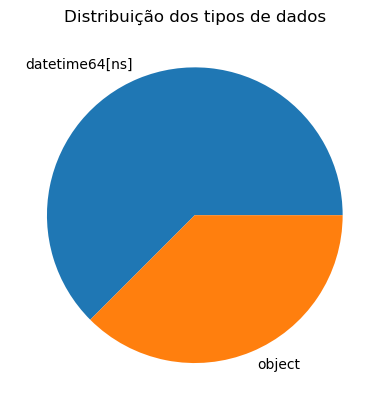

In [7]:
df_orders.dtypes.value_counts().plot(kind = "pie")
plt.title("Distribuição dos tipos de dados")
plt.ylabel("")
plt.xlabel("")
plt.show()

## Análise consistência temporal

In [8]:
(df_orders["order_purchase_timestamp"] > df_orders["order_approved_at"]).sum()

np.int64(0)

In [9]:
(df_orders["order_approved_at"] > df_orders["order_delivered_carrier_date"]).sum()

np.int64(1359)

ℹ️ Existem inconsistência nos dados, pois o valor retornado é maior que zero, evidenciando que há pedidos que foram aprovados após serem postados aos fornecedores

In [10]:
mask = df_orders["order_approved_at"] > df_orders["order_delivered_carrier_date"]

df_orders[mask].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,2018-07-31
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42,2018-07-31
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39,2018-08-06


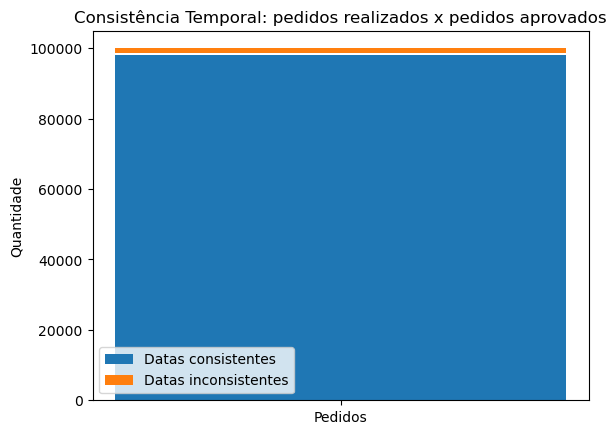

In [11]:
counts = mask.value_counts()

true_count = counts.get(True, 0)
false_count = counts.get(False, 0)

plt.bar("Pedidos", false_count, label = "Datas consistentes")
plt.bar("Pedidos", true_count, bottom = false_count + 500, label = "Datas inconsistentes")

plt.title("Consistência Temporal: pedidos realizados x pedidos aprovados")
plt.ylabel("Quantidade")

plt.legend()
plt.show()

In [12]:
(df_orders["order_delivered_carrier_date"] > df_orders["order_delivered_customer_date"]).sum()

np.int64(23)

ℹ️ Existem inconsistência nos dados, pois o valor retornado é maior que zero, evidenciando que há pedidos que foram apenas postados para os fornecedores após sua entrega ao cliente

In [13]:
mask = df_orders["order_delivered_carrier_date"] > df_orders["order_delivered_customer_date"]

df_orders[mask].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31


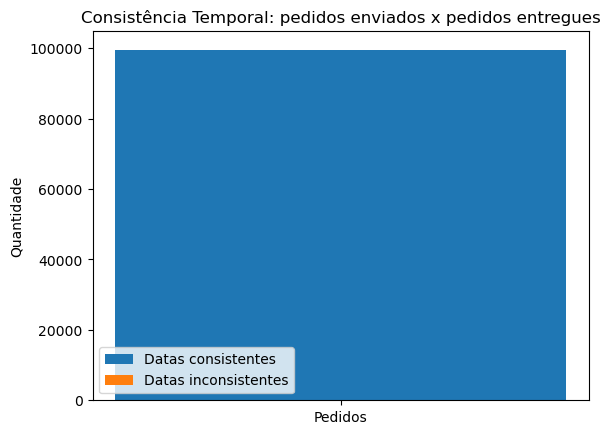

In [14]:
counts = mask.value_counts()

true_count = counts.get(True, 0)
false_count = counts.get(False, 0)

plt.bar("Pedidos", false_count, label = "Datas consistentes")
plt.bar("Pedidos", true_count, bottom = false_count + 500, label = "Datas inconsistentes")

plt.title("Consistência Temporal: pedidos enviados x pedidos entregues")
plt.ylabel("Quantidade")

plt.legend()
plt.show()

## Análise de colunas categóricas

In [15]:
colunas_categoricas = [
    "order_status",
]

print(f'Porcentagem das colunas categóricas:\n\
{df_orders[colunas_categoricas].value_counts(normalize = True).mul(100).round(2)}\n\n\
Valor absoluto das colunas categóricas:\n\
{df_orders[colunas_categoricas].value_counts()}')

Porcentagem das colunas categóricas:
order_status
delivered       97.02
shipped          1.11
canceled         0.63
unavailable      0.61
invoiced         0.32
processing       0.30
created          0.01
approved         0.00
Name: proportion, dtype: float64

Valor absoluto das colunas categóricas:
order_status
delivered       96478
shipped          1107
canceled          625
unavailable       609
invoiced          314
processing        301
created             5
approved            2
Name: count, dtype: int64


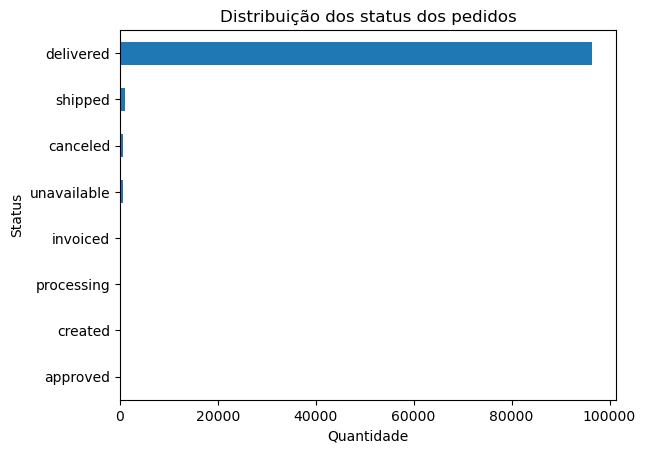

In [16]:
df_orders["order_status"].value_counts().sort_values().plot(kind = "barh")

plt.title("Distribuição dos status dos pedidos")
plt.ylabel("Status")
plt.xlabel("Quantidade")

plt.show()

## Análise de nulos

In [17]:
print(f'Porcentagem de valores nulos:\n\
{df_orders.isnull().mean().mul(100).round(2).sort_values(ascending = False)}\n\n\
Valor absoluto de nulos:\n\
{df_orders.isnull().sum().sort_values(ascending = False)}')

Porcentagem de valores nulos:
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
order_id                         0.00
order_purchase_timestamp         0.00
order_status                     0.00
customer_id                      0.00
order_estimated_delivery_date    0.00
dtype: float64

Valor absoluto de nulos:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64


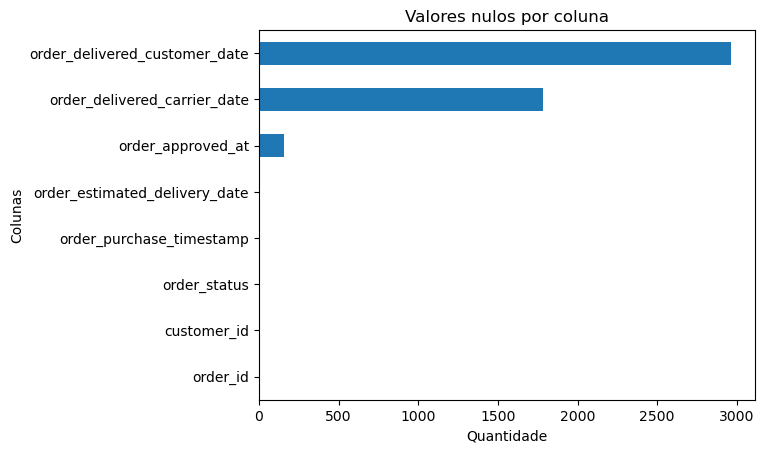

In [18]:
df_orders.isnull().sum().sort_values().plot(kind = "barh")

plt.title("Valores nulos por coluna")
plt.ylabel("Colunas")
plt.xlabel("Quantidade")

plt.show()

In [19]:
df_orders.groupby("order_status")[colunas_de_data].apply(lambda x: x.isnull().mean()).mul(100).round(2)

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0.0,0.00,100.0,100.00,0.0
canceled,0.0,22.56,88.0,99.04,0.0
created,0.0,100.00,100.0,100.00,0.0
delivered,0.0,0.01,0.0,0.01,0.0
invoiced,0.0,0.00,100.0,100.00,0.0
processing,0.0,0.00,100.0,100.00,0.0
shipped,0.0,0.00,0.0,100.00,0.0
unavailable,0.0,0.00,100.0,100.00,0.0


ℹ️ Ao analisar células acima, concluí-se que os dados nulos não representam raído nos dados, mas devido às regras de negócio

## Análise de duplicidades

In [20]:
df_orders.duplicated().sum()

np.int64(0)

ℹ️ Não há registros duplicados, pois o valor retornado é igual a zero

## Análise de PK e cardinalidade

In [21]:
df_orders.nunique().div(len(df_orders)).sort_values(ascending = False)

order_id                         1.000000
customer_id                      1.000000
order_purchase_timestamp         0.994308
order_delivered_customer_date    0.962018
order_approved_at                0.912430
order_delivered_carrier_date     0.814734
order_estimated_delivery_date    0.004616
order_status                     0.000080
dtype: float64

ℹ️ Como analisar?
```
1.0       -> Possível chave / identificador
0.95-0.99 -> Possível chave, mas com possíveis erros 
0.5-0.95  -> Relacionamento (1:N)
< 0.5     -> Não deve ser um identificaor, pois há alta repetição
```

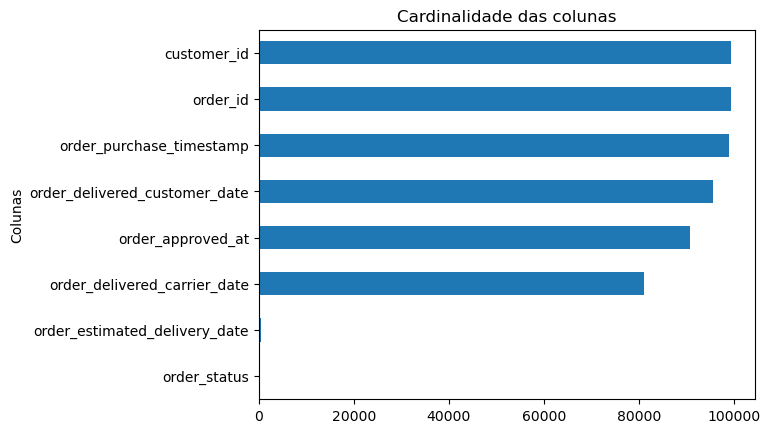

In [22]:
df_orders.nunique().sort_values().plot(kind = "barh")

plt.title("Cardinalidade das colunas")
plt.ylabel("Colunas")
plt.xlabel("")

plt.show()

ℹ️ Com base nas análises realizadas acima, consluí-se que a PK é composta por `order_id` 

---

# Análise Exploratória de *olist_order_items_dataset.csv*

### Carregamento dos dados e inspeção inicial

In [23]:
df_order_items = pd.read_csv("./olist_order_items_dataset.csv")

In [24]:
df_order_items.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
90818,ce48e13a260d1585d74a5c4e0a830e6c,1,6743237ac224ec25a57fcc1b07197f64,fe1bbc5feda5c8979a8a1b3b2512d5a6,2017-07-20 03:25:41,29.90,15.10
43308,627c1c31327bda6f11b5e7c613f1d366,1,0bc5e6c957486577f11519bf36577b38,1eade46fba20122dc4aefb379f8c636b,2017-07-14 19:45:15,21.99,14.10
87061,c5b4cf4aabaf93ce294452d114ae22a1,1,23227b07fc69250d2fa4be6602011aea,e38db885400cd35c71dfd162f2c1dbcf,2018-01-25 11:57:47,64.90,19.69
44854,660184ce8221d07e9acefb645947f761,2,34c8873cadb5465f46b7a20b6eb0215b,f214d28e8d8e3ef068748498ccc2f813,2018-05-09 23:15:14,24.99,0.98
80506,b7261927790781e114d3a12f39ef44c0,2,0d85c435fd60b277ffb9e9b0f88f927a,f457c46070d02cadd8a68551231220dd,2018-03-23 11:30:57,72.00,13.62


In [25]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


### Análise das colunas numéricas

In [26]:
colunas_numericas = [
    "order_item_id",
    "price",
    "freight_value"
]

df_order_items[colunas_numericas].describe().round(2)

,order_item_id,price,freight_value
count,112650.00,112650.00,112650.00
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,6735.00,409.68


In [27]:
df_order_items[(df_order_items["order_item_id"] <= 0) | (df_order_items["price"] < 0) | (df_order_items["freight_value"] < 0)].shape[0]

0

### Conversão de tipos

In [28]:
colunas_de_data = [
    "shipping_limit_date"
]

df_order_items[colunas_de_data] = df_order_items[colunas_de_data].apply(pd.to_datetime , errors = "coerce")

df_order_items[colunas_de_data].dtypes

shipping_limit_date    datetime64[ns]
dtype: object

### Análise de nulos

In [29]:
print(f'Porcentagem:\n{df_order_items.isnull().mean().mul(100).round(2).sort_values(ascending = False)}\n\nValor absoluto:\n{df_order_items.isnull().sum().sort_values(ascending = False)}')

Porcentagem:
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64

Valor absoluto:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


### Análise de duplicidades

In [30]:
df_order_items.duplicated().sum()

np.int64(0)

### Análise de PK e cardinalidade

In [31]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_order_items.nunique().div(len(df_order_items)).round(2).sort_values(ascending = False)

order_id               0.88
shipping_limit_date    0.83
product_id             0.29
freight_value          0.06
price                  0.05
seller_id              0.03
order_item_id          0.00
dtype: float64

In [32]:
df_order_items.duplicated(subset = ["order_id", "order_item_id"]).sum()

np.int64(0)

In [33]:
len(df_order_items[["order_id", "order_item_id"]].drop_duplicates()) / len(df_order_items)

1.0

# Análise Exploratória de *olist_order_payments_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [34]:
df_order_payments = pd.read_csv("./olist_order_payments_dataset.csv")

In [35]:
df_order_payments.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51539,d0f4fe13d39b8c71a0d1f21ab65192c0,1,boleto,1,148.87
58588,e7b01e38e214dfdeaa5c9c98f911a7e4,2,voucher,1,33.20
57641,0fb1f7c7042e9fa84d8d415c5fdec5c9,1,credit_card,1,29.10
86401,6ea9f2cd206705f2638e4d3db4698031,1,credit_card,6,133.68
64330,e99a451628b46086835d5da0bd58c932,1,credit_card,1,69.62


In [36]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


### Análise de colunas categóricas

In [37]:
colunas_categoricas = [
    "payment_type"
]

print(f'Porcentagem:\n{df_order_payments[colunas_categoricas].value_counts(normalize = True).mul(100).round(2)}\n\nValor absoluto:\n{df_order_payments[colunas_categoricas].value_counts()}')

Porcentagem:
payment_type
credit_card     73.92
boleto          19.04
voucher          5.56
debit_card       1.47
not_defined      0.00
Name: proportion, dtype: float64

Valor absoluto:
payment_type
credit_card     76795
boleto          19784
voucher          5775
debit_card       1529
not_defined         3
Name: count, dtype: int64


### Análise das colunas numéricas

In [38]:
colunas_numericas = [
    "payment_sequential",
    "payment_installments",
    "payment_value"
]

df_order_payments[colunas_numericas].describe().round(2)

,payment_sequential,payment_installments,payment_value
count,103886.00,103886.00,103886.00
mean,1.09,2.85,154.10
std,0.71,2.69,217.49
min,1.00,0.00,0.00
25%,1.00,1.00,56.79
50%,1.00,1.00,100.00
75%,1.00,4.00,171.84
max,29.00,24.00,13664.08


In [39]:
df_order_payments[(df_order_payments["payment_sequential"] <= 0) | (df_order_payments["payment_installments"] <= 0) | (df_order_payments["payment_value"] <= 0)]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.00
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.00
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.00
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.00
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.00
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.00
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.00
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.00


### Análise de nulos

In [40]:
print(f'Porcentagem:\n{df_order_payments.isnull().mean().mul(100).round(2)}\n\nValor absoluto:\n{df_order_payments.isnull().sum()}')

Porcentagem:
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64

Valor absoluto:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


### Análise de duplicidades

In [41]:
df_order_payments.duplicated().sum()

np.int64(0)

### Análise de PK e cardinalidade

In [42]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_order_payments.nunique().div(len(df_order_payments)).sort_values(ascending = False)

order_id                0.957203
payment_value           0.279893
payment_sequential      0.000279
payment_installments    0.000231
payment_type            0.000048
dtype: float64

In [43]:
'''
Caso o valor seja igual a 0 .: possível chave composta
'''
df_order_payments.duplicated(subset = ["order_id", "payment_sequential"]).sum()

np.int64(0)

In [44]:
'''
Caso o valor seja igual a 1.0 .: possível chave composta
'''
len(df_order_payments[["order_id", "payment_sequential"]].drop_duplicates()) / len(df_order_payments)

1.0

# Análise Exploratória de *olist_order_reviews_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [45]:
df_order_reviews = pd.read_csv("./olist_order_reviews_dataset.csv")

In [46]:
df_order_reviews.sample(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
37965,1a41024a69f98c495962be70be0519ab,1e0efbb6f899f5f08e26951b1e170387,3,NaN,porem não recebi meus produtos Ainda,2017-04-12 00:00:00,2017-04-17 10:02:57
24855,9f98c17fd117aef60d72f3f94338232e,5e0ff060a686922559e33f8dbe998e41,5,NaN,NaN,2018-08-14 00:00:00,2018-08-17 00:38:22
18449,17a8ef640c95b47eac4b990377b1e2fb,cb6788e2b64ab1ddde45555de93c809f,4,NaN,Muito bom deveria ter outro tom de rosa mais e...,2017-12-15 00:00:00,2017-12-16 14:53:07
7426,40d02267c56d902bea401dbbdfa37298,448645ea240ea7aa0dcc61d2cad9eb5d,5,NaN,"Bem pequeno, de acordo com o espaço que eu ten...",2017-12-05 00:00:00,2017-12-07 00:51:08
77751,0cf3a75a3cc2470d010e79e0242e1daf,b3c20d53be137128e8ae69ee76a60326,5,NaN,NaN,2017-05-11 00:00:00,2017-05-14 15:25:39


In [47]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


### Conversão de tipos

In [48]:
colunas_de_data = [
    "review_creation_date",
    "review_answer_timestamp"
]

df_order_reviews[colunas_de_data] = df_order_reviews[colunas_de_data].apply(pd.to_datetime, errors = "coerce")

df_order_reviews[colunas_de_data].dtypes

review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

### Análise consistência temporal:

In [49]:
(df_order_reviews["review_creation_date"] > df_order_reviews["review_answer_timestamp"]).sum()

np.int64(0)

### Análise de colunas categóricas

In [50]:
colunas_categoricas = [
    "review_score"
]

print(f'Porcentagem:\n{df_order_reviews["review_score"].value_counts(normalize = True).mul(100).round(2).sort_values(ascending = False)}\n\nValor absoluto:\n{df_order_reviews[colunas_categoricas].value_counts().sort_values(ascending = False)}')

Porcentagem:
review_score
5    57.78
4    19.29
1    11.51
3     8.24
2     3.18
Name: proportion, dtype: float64

Valor absoluto:
review_score
5               57328
4               19142
1               11424
3                8179
2                3151
Name: count, dtype: int64


### Análise de nulos

In [51]:
print(f'Porcentagem:\n{df_order_reviews.isnull().sum().sort_values(ascending = False)}\n\nValor absoluto:\n{df_order_reviews.isnull().mean().mul(100).round(2).sort_values(ascending = False)}')

Porcentagem:
review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Valor absoluto:
review_comment_title       88.34
review_comment_message     58.70
review_id                   0.00
review_score                0.00
order_id                    0.00
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64


In [52]:
df_order_reviews.groupby("review_score")[["review_comment_title", "review_comment_message"]].apply(lambda x: x.isnull().mean().mul(100).round(2))

,review_comment_title,review_comment_message
review_score,,
1,83.60,23.45
2,84.83,31.93
3,89.93,56.51
4,90.94,68.78
5,88.39,64.15


### Análise de duplicidades

In [53]:
df_order_reviews.duplicated().sum()

np.int64(0)

### Análise de PK e cardinalidade

In [54]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_order_reviews.nunique().div(len(df_order_reviews)).sort_values(ascending = False)

order_id                   0.994447
review_id                  0.991796
review_answer_timestamp    0.990164
review_comment_message     0.364418
review_comment_title       0.045624
review_creation_date       0.006410
review_score               0.000050
dtype: float64

In [55]:
'''
Caso o valor seja igual a 0 .: possível chave composta
'''
df_order_reviews.duplicated(subset = ["review_id", "order_id"]).sum()

np.int64(0)

In [56]:
'''
Caso o valor seja igual a 1.0 .: possível chave composta
'''
len(df_order_reviews[["review_id", "order_id"]].drop_duplicates()) / len(df_order_reviews)

1.0

## Análise Exploratória de *olist_products_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [57]:
df_products = pd.read_csv("./olist_products_dataset.csv")

In [58]:
df_products.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18837,7e6850f360e60da72b7d3b1b37f42312,informatica_acessorios,59.0,859.0,3.0,800.0,33.0,11.0,14.0
24996,4463c4f83cecd53e81653bab5b41a0d9,papelaria,53.0,1665.0,3.0,3550.0,46.0,7.0,46.0
24446,4293865e4ead3d446609086b4cfedb4f,cama_mesa_banho,59.0,189.0,1.0,1650.0,46.0,3.0,34.0
20075,3a1d765ba460f89749b9db2c1889140c,telefonia,56.0,771.0,1.0,100.0,19.0,4.0,11.0
2866,73df0070248804951b5c6ba9537c6fc3,NaN,NaN,NaN,NaN,100.0,16.0,6.0,11.0


In [59]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


### Análise de colunas categóricas

In [60]:
colunas_categoricas = [
    "product_category_name"
]

print(f'Porcentagem:\n{df_products[colunas_categoricas].value_counts(normalize = True).mul(100).round(2)}\n\nValor absoluto:\n{df_products[colunas_categoricas].value_counts()}')

Porcentagem:
product_category_name        
cama_mesa_banho                  9.37
esporte_lazer                    8.86
moveis_decoracao                 8.22
beleza_saude                     7.56
utilidades_domesticas            7.22
                                 ... 
casa_conforto_2                  0.02
fashion_roupa_infanto_juvenil    0.02
pc_gamer                         0.01
seguros_e_servicos               0.01
cds_dvds_musicais                0.00
Name: proportion, Length: 73, dtype: float64

Valor absoluto:
product_category_name        
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
casa_conforto_2                     5
fashion_roupa_infanto_juvenil       5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtyp

### Análise das colunas numéricas

In [61]:
colunas_numericas = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

df_products[colunas_numericas].describe().round(2)

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00
mean,48.48,771.50,2.19,2276.47,30.82,16.94,23.20
std,10.25,635.12,1.74,4282.04,16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,1900.00,38.00,21.00,30.00
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00


In [62]:
df_products[(df_products[colunas_numericas] <= 0).any(axis = 1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


### Análise de nulos

In [63]:
print(f'Porcentagem:\n{df_products.isnull().mean().mul(100).round(2)}\n\nValor absoluto:\n{df_products.isnull().sum()}')

Porcentagem:
product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

Valor absoluto:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


### Análise de duplicidades

In [64]:
df_products.duplicated().sum()

np.int64(0)

### Análise de PK e cardinalidade

In [65]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_products.nunique().div(len(df_products)).round(2).sort_values(ascending = False)

product_id                    1.00
product_description_lenght    0.09
product_weight_g              0.07
product_name_lenght           0.00
product_category_name         0.00
product_photos_qty            0.00
product_length_cm             0.00
product_height_cm             0.00
product_width_cm              0.00
dtype: float64

---

# Análise Exploratória de *olist_customers_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [66]:
df_costumers = pd.read_csv("./olist_customers_dataset.csv")

In [67]:
df_costumers.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
499,e0c77096ebcb9aedc1c613ac43e0ccfc,c7a2cdaf9d8bf3ad353e055e39024bfd,89825,xaxim,SC
42406,b0669f166cacfeef78736fe97ecfb657,134b6710b2c9d9f006d75e0bcd4794b0,29901,linhares,ES
10135,5626650d4ff662ebbb6bcd7e126fd6d7,88b24eae074d0cb324262f6df017ab21,89208,joinville,SC
70786,82060ef3e1a400c3176bcf87717e1685,ffc14413ed1273340b518ad0bc63c862,13236,campo limpo paulista,SP
52326,6a909b62463d9c6cc4126cea7af3ad59,7b06aa5473c44b8e05b9eeaea702f1a2,4026,sao paulo,SP


In [68]:
df_costumers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


### Conversão de tipos

In [69]:
df_costumers["customer_zip_code_prefix"] = df_costumers["customer_zip_code_prefix"].astype(str)

In [70]:
df_costumers["customer_zip_code_prefix"].dtype

dtype('O')

### Análise de colunas categóricas

In [71]:
colunas_categoricas = [
    "customer_city",
    "customer_state"
]

print(f'Porcentagem de cidades:\n\
{df_costumers["customer_city"].value_counts(normalize =True).mul(100).round(2)}\
\n\nValor absoluto das cidades:\n\
{df_costumers["customer_city"].value_counts()}\n\
\n-------------------------------------------------- \n\n\
Porcentagem dos estados (UF):\n\
{df_costumers["customer_state"].value_counts(normalize = True).mul(100).round(2)}\
\n\nValor absoluto dos estados (UF)\n\
{df_costumers["customer_state"].value_counts()}')

Porcentagem de cidades:
customer_city
sao paulo                   15.63
rio de janeiro               6.92
belo horizonte               2.79
brasilia                     2.14
curitiba                     1.53
                            ...  
olhos d'agua                 0.00
pacotuba                     0.00
sao sebastiao do paraiba     0.00
benedito leite               0.00
campos verdes                0.00
Name: proportion, Length: 4119, dtype: float64

Valor absoluto das cidades:
customer_city
sao paulo                   15540
rio de janeiro               6882
belo horizonte               2773
brasilia                     2131
curitiba                     1521
                            ...  
olhos d'agua                    1
pacotuba                        1
sao sebastiao do paraiba        1
benedito leite                  1
campos verdes                   1
Name: count, Length: 4119, dtype: int64

-------------------------------------------------- 

Porcentagem dos estados (UF):


### Análise de nulos

In [72]:
print(f'Porcentagem:\n\
{df_costumers.isnull().mean().mul(100).round(2)}\n\n\
Valor absoluto:\n\
{df_costumers.isnull().sum()}')

Porcentagem:
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64

Valor absoluto:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


### Análise de duplicidades

In [73]:
df_costumers.duplicated().sum()

np.int64(0)

### Análise de PK e cardinalidade

In [74]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_costumers.nunique().div(len(df_costumers)).round(2).sort_values(ascending = False)

customer_id                 1.00
customer_unique_id          0.97
customer_zip_code_prefix    0.15
customer_city               0.04
customer_state              0.00
dtype: float64

In [75]:
df_costumers.groupby("customer_unique_id")["customer_id"].nunique().sort_values(ascending = False)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
ffeefd086fc667aaf6595c8fe3d22d54     1
ffef0ffa736c7b3d9af741611089729b     1
fff1afc79f6b5db1e235a4a6c30ceda7     1
fff1bdd5c5e37ca79dd74deeb91aa5b6     1
fff22793223fe80c97a8fd02ac5c6295     1
Name: customer_id, Length: 96096, dtype: int64

> costumer_unique_id **1 : N** costumer_id

---

# Análise Exploratória de *olist_sellers_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [76]:
df_sellers = pd.read_csv("./olist_sellers_dataset.csv")

In [77]:
df_sellers.sample(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
2813,e48b04bf1aa1ef711caebeb7aede6180,80240,curitiba,PR
2805,544863df86ed3b78a04e0820d41430ee,29166,serra,ES
2362,15ac3c501e2599e4917316fde5c5669a,4911,sao paulo,SP
450,9ac75591b69c3402684b6ce0310f22ee,2880,sao paulo,SP
359,822b63912576852aea9a8436d72317b7,13840,mogi guacu,SP


In [78]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


### Conversão de tipos

In [79]:
df_sellers["seller_zip_code_prefix"] = df_sellers["seller_zip_code_prefix"].astype(str)

In [80]:
df_sellers.dtypes

seller_id                 object
seller_zip_code_prefix    object
seller_city               object
seller_state              object
dtype: object

### Análise de colunas categóricas

In [81]:
print(f'Porcentagem das cidades:\n\
{df_sellers["seller_city"].value_counts(normalize = True).mul(100).round(2)}\n\n\
Valor absoluto das cidades:\n\
{df_sellers["seller_city"].value_counts()}\n\n\
--------------------------------------------------\n\n\
Porcentagem dos estados (UFs):\n\
{df_sellers["seller_state"].value_counts(normalize = True).mul(100).round(2)}\n\n\
Valor absoluto dos estados (UFs):\n\
{df_sellers["seller_state"].value_counts()}\
')

Porcentagem das cidades:
seller_city
sao paulo                                 22.42
curitiba                                   4.10
rio de janeiro                             3.10
belo horizonte                             2.20
ribeirao preto                             1.68
                                          ...  
ipua                                       0.03
muqui                                      0.03
timoteo                                    0.03
pouso alegre                               0.03
rio de janeiro, rio de janeiro, brasil     0.03
Name: proportion, Length: 611, dtype: float64

Valor absoluto das cidades:
seller_city
sao paulo                                 694
curitiba                                  127
rio de janeiro                             96
belo horizonte                             68
ribeirao preto                             52
                                         ... 
ipua                                        1
muqui                     

### Análise de nulos

In [82]:
print(f'Porcentagem:\n\
{df_sellers.isnull().mean().mul(100).round(2)}\n\n\
Valor absoluto:\n\
{df_sellers.isnull().sum()}')

Porcentagem:
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64

Valor absoluto:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


### Análise de PK e cardinalidade

### Análise de duplicidades

In [83]:
df_sellers.duplicated().sum()

np.int64(0)

In [84]:
'''
1.0         -> Possível chave
0.95 - 0.99 -> Possível chave, mas com erros 
0.5 - 0.95  -> Relacionamento (1:N)
< 0.5       -> Alta repetição .: a coluna não identifica 
'''
df_sellers.nunique().div(len(df_sellers)).round(2).sort_values(ascending = False)

seller_id                 1.00
seller_zip_code_prefix    0.73
seller_city               0.20
seller_state              0.01
dtype: float64

---

# Análise Exploratória de *olist_geolocation_dataset.csv*

### Carregamento dos dados e inpeção inicial

In [85]:
df_geolocation = pd.read_csv("./olist_geolocation_dataset.csv")

In [86]:
df_geolocation.sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
161241,6436,-23.536253,-46.883477,barueri,SP
852614,81650,-25.488154,-49.237291,curitiba,PR
699136,47665,-13.401730,-44.195119,sao felix do coribe,BA
408124,20221,-22.902100,-43.189832,rio de janeiro,RJ
57863,3478,-23.573058,-46.512633,sao paulo,SP


In [87]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


### Conversão de tipos

In [88]:
df_geolocation["geolocation_zip_code_prefix"] = df_geolocation["geolocation_zip_code_prefix"].astype(str)

In [89]:
df_geolocation.dtypes

geolocation_zip_code_prefix     object
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

### Análise de nulos

In [90]:
print(f'Porcentagem:\n\
{df_geolocation.isnull().mean().mul(100).round(2).sort_values(ascending = False)}\n\n\
Valor absoluto:\n\
{df_geolocation.isnull().sum()}')

Porcentagem:
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64

Valor absoluto:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


### Análise de duplicidades

In [91]:
df_geolocation.duplicated().sum()

np.int64(261831)

In [92]:
mask = df_geolocation.duplicated()
df_geolocation[mask]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


### Análise de PK e cardinalidade

In [93]:
df_geolocation.nunique().div(len(df_geolocation)).round(2).sort_values(ascending = False)

geolocation_lat                0.72
geolocation_lng                0.72
geolocation_zip_code_prefix    0.02
geolocation_city               0.01
geolocation_state              0.00
dtype: float64

---

# Identificação dos relacionamentos entre as tabelas

ℹ️ Caso os valores retornados sejam iguais a um, evidenciará que aquele campo representa uma FK

In [94]:
df_orders["customer_id"].isin(df_costumers["customer_id"]).mean()

np.float64(1.0)

In [95]:
df_order_items["order_id"].isin(df_orders["order_id"]).mean()

np.float64(1.0)

In [96]:
df_order_items["product_id"].isin(df_products["product_id"]).mean()

np.float64(1.0)

In [97]:
df_order_items["seller_id"].isin(df_sellers["seller_id"]).mean()

np.float64(1.0)

In [98]:
df_order_payments["order_id"].isin(df_orders["order_id"]).mean()

np.float64(1.0)

In [99]:
df_order_reviews["order_id"].isin(df_orders["order_id"]).mean()

np.float64(1.0)

In [100]:
df_costumers["customer_zip_code_prefix"].isin(df_geolocation["geolocation_zip_code_prefix"]).mean()

np.float64(0.9972043724419505)

In [101]:
df_sellers["seller_zip_code_prefix"].isin(df_geolocation["geolocation_zip_code_prefix"]).mean()

np.float64(0.9977382875605816)

ℹ️ Como analisar?
```
99% correspondem 
1% não corresponde
```
Neste *dataset* o prefixo do CEP foi truncado para apenas os cinco primeiros dígitos (anonimização). Devido a isso, nota-se que alguns prefixos não estejam em *df_geolocation*, além deste possuir inúmeras duplicatas, invalidando os critérios parta torna-se um FK limpa

In [102]:
mask1 = ~df_costumers["customer_zip_code_prefix"].isin(df_geolocation["geolocation_zip_code_prefix"])
mask2 = ~df_sellers["seller_zip_code_prefix"].isin(df_geolocation["geolocation_zip_code_prefix"])

print(f'1% equivale {df_costumers[mask1].shape[0]} registros em df_costumers')
print(f'1% equivale {df_sellers[mask2].shape[0]} registros em df_sellers')

1% equivale 278 registros em df_costumers
1% equivale 7 registros em df_sellers


In [103]:
df_costumers.loc[mask1].sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
7410,77b5832eda477c951c0f2b13998ddfa2,791196cf7e5c2e2a7e894884becd7a6c,72005,brasilia,DF
54461,54c9809e0315ee825c01a3bbe1cd61b7,c5c8e42080d2712f53984e95d9864871,77404,gurupi,TO
45658,52e73a5d0a1d4c56b090cd70e0d678ee,b43530186123fb6d906380c873fdd9e6,62625,missi,CE
29996,0abda7ee9b75764b3bf4197b63ee7c0a,a28a5bf286affa0abc5f7dbc1ccb6a2d,73255,brasilia,DF
77072,a63d4ed214b0406558f633a39c61bac4,5a465fa8d582b46073747a7a0dafb516,71551,brasilia,DF


In [104]:
df_sellers.loc[mask2]

,seller_id,seller_zip_code_prefix,seller_city,seller_state
473,5962468f885ea01a1b6a97a218797b0a,82040,curitiba,PR
791,2aafae69bf4c41fbd94053d9413e87ee,91901,porto alegre,RS
1672,2a50b7ee5aebecc6fd0ff9784a4747d6,72580,brasilia,DF
1931,2e90cb1677d35cfe24eef47d441b7c87,2285,sao paulo,SP
2182,0b3f27369a4d8df98f7eb91077e438ac,7412,aruja,SP
2986,42bde9fef835393bb8a8849cb6b7f245,71551,brasilia,DF
3028,870d0118f7a9d85960f29ad89d5d989a,37708,pocos de caldas,MG
